# 06 · Inside the CMFM block

No training: we open the Cross-Modal Fusion Mamba block and check its claimed properties with tensors in hand.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot` |
| **Expected runtime** | about 2 minutes |
| **Produces** | nothing; this notebook is for understanding and checking |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


## 0. The method in three pictures

**CFFM-Net.** Two YOLO26-n backbones, one per sensor, fused at P2 by a reliability-weighted sum and at P3 to
P5 by CMFM. The fused maps feed YOLO26's stride-4 PAN neck and its NMS-free heads.

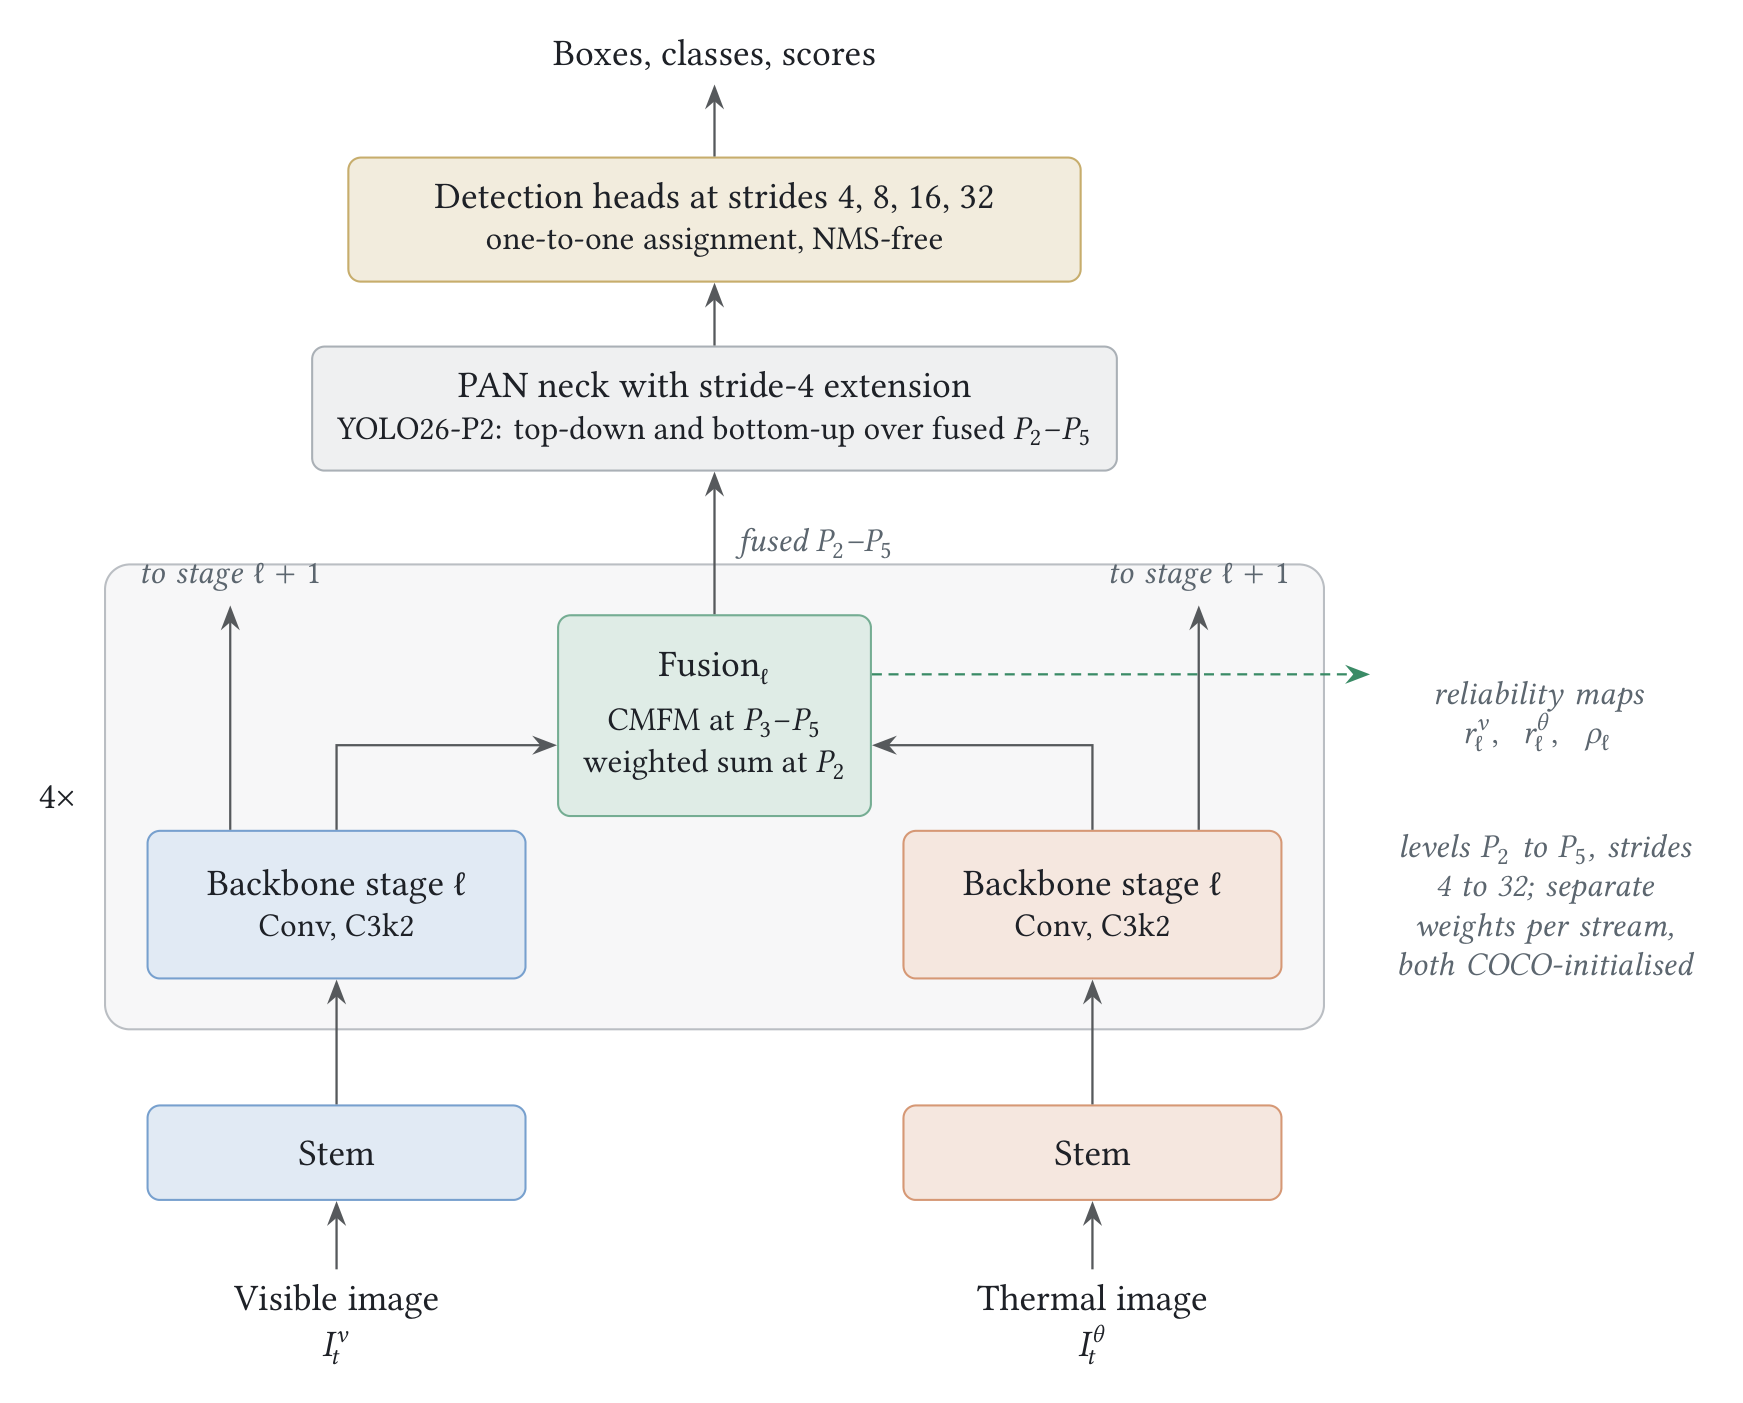

In [2]:
from IPython.display import Image, display
for name in ('fig_architecture',):
    f = env.project / "docs" / "figures" / f"{name}.png"
    if f.exists():
        display(Image(filename=str(f), width=700))
    else:
        print("missing", f)

**CMFM.** A per-location reliability score gates the scan and weights the residual, after thermal is aligned
by a learned offset. The two streams are interleaved token by token and scanned in four directions.

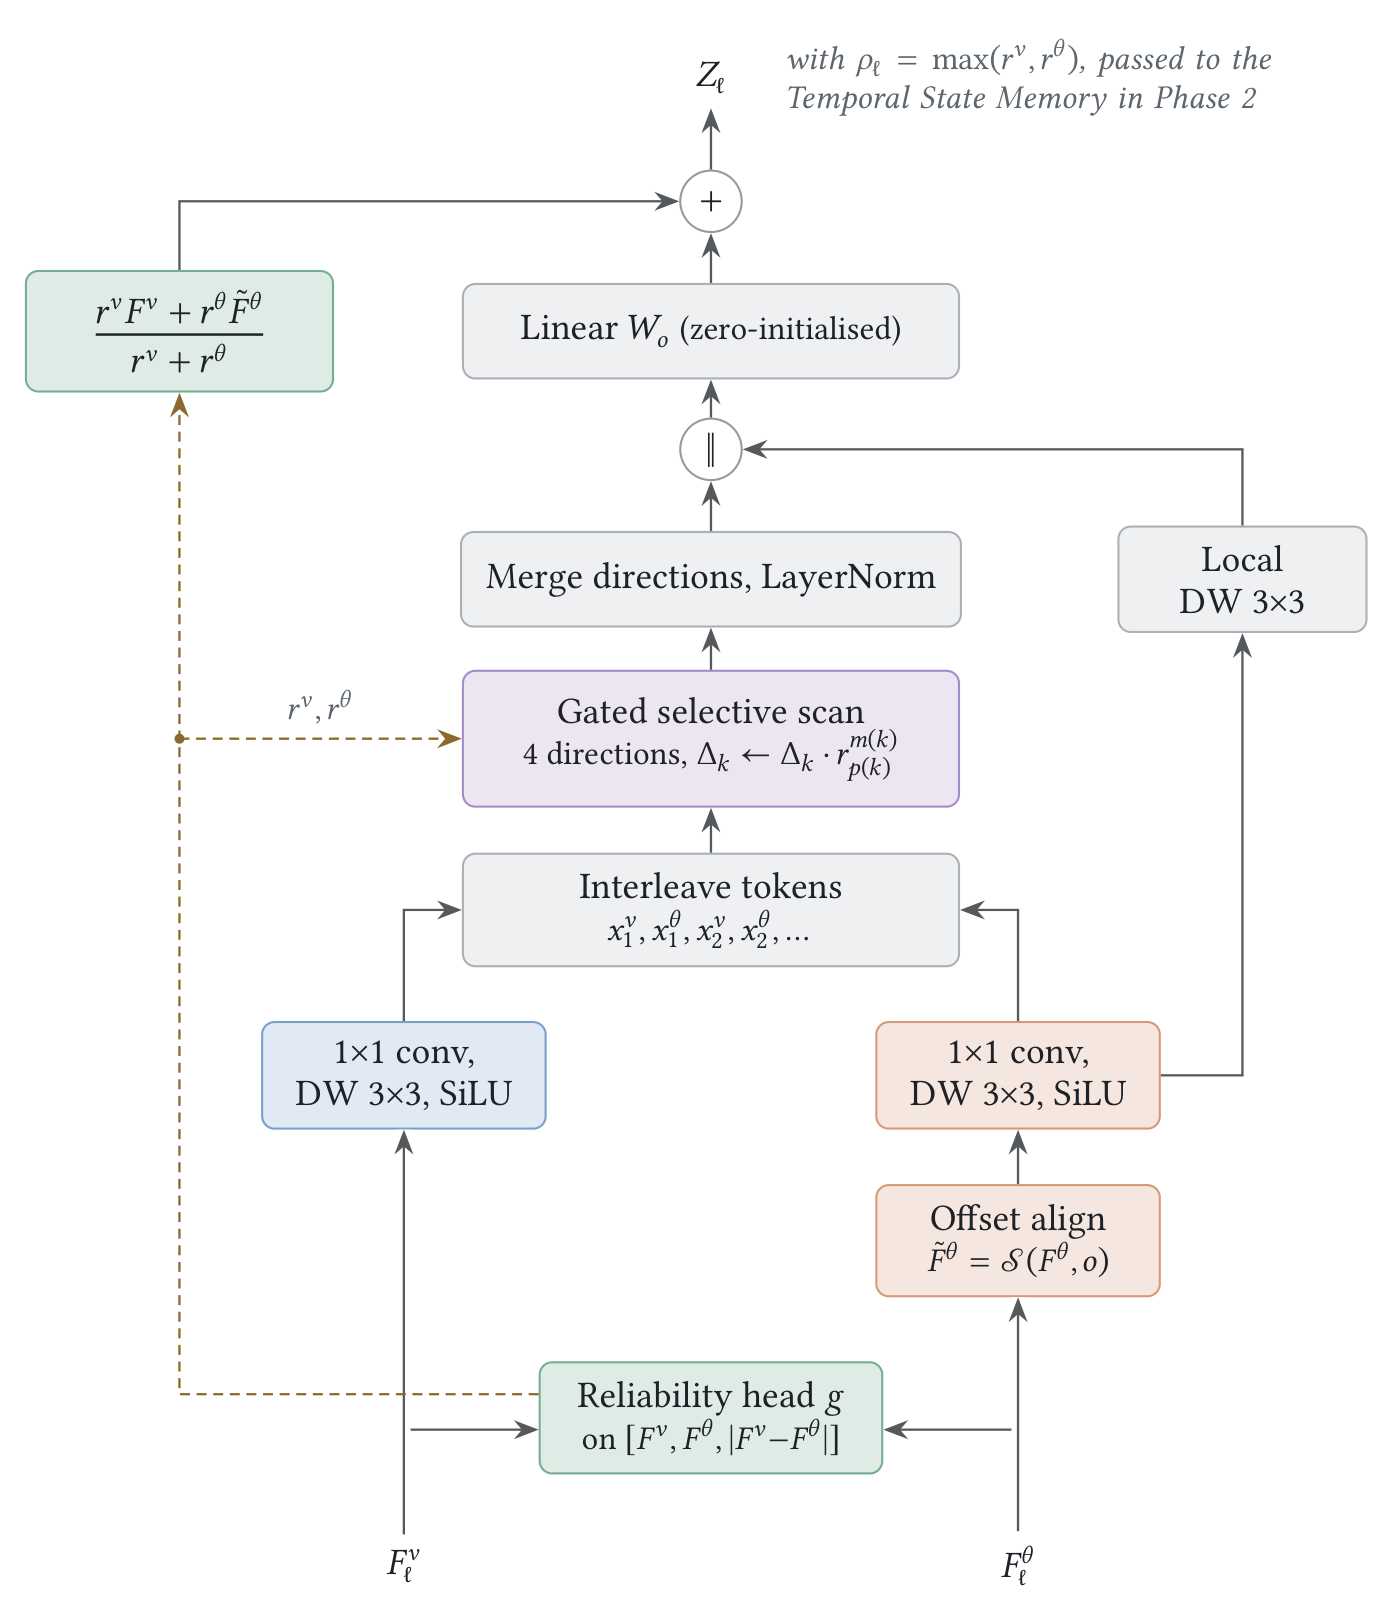

In [3]:
from IPython.display import Image, display
for name in ('fig_cmfm',):
    f = env.project / "docs" / "figures" / f"{name}.png"
    if f.exists():
        display(Image(filename=str(f), width=640))
    else:
        print("missing", f)

**The gated recurrence.** Each token's step $\Delta_k$ is multiplied by the reliability $r_k$ of its sensor.
As $r_k \to 0$, $\bar A_k \to 1$ and $\bar B_k \to 0$, so the token neither writes into the state nor
erases it.

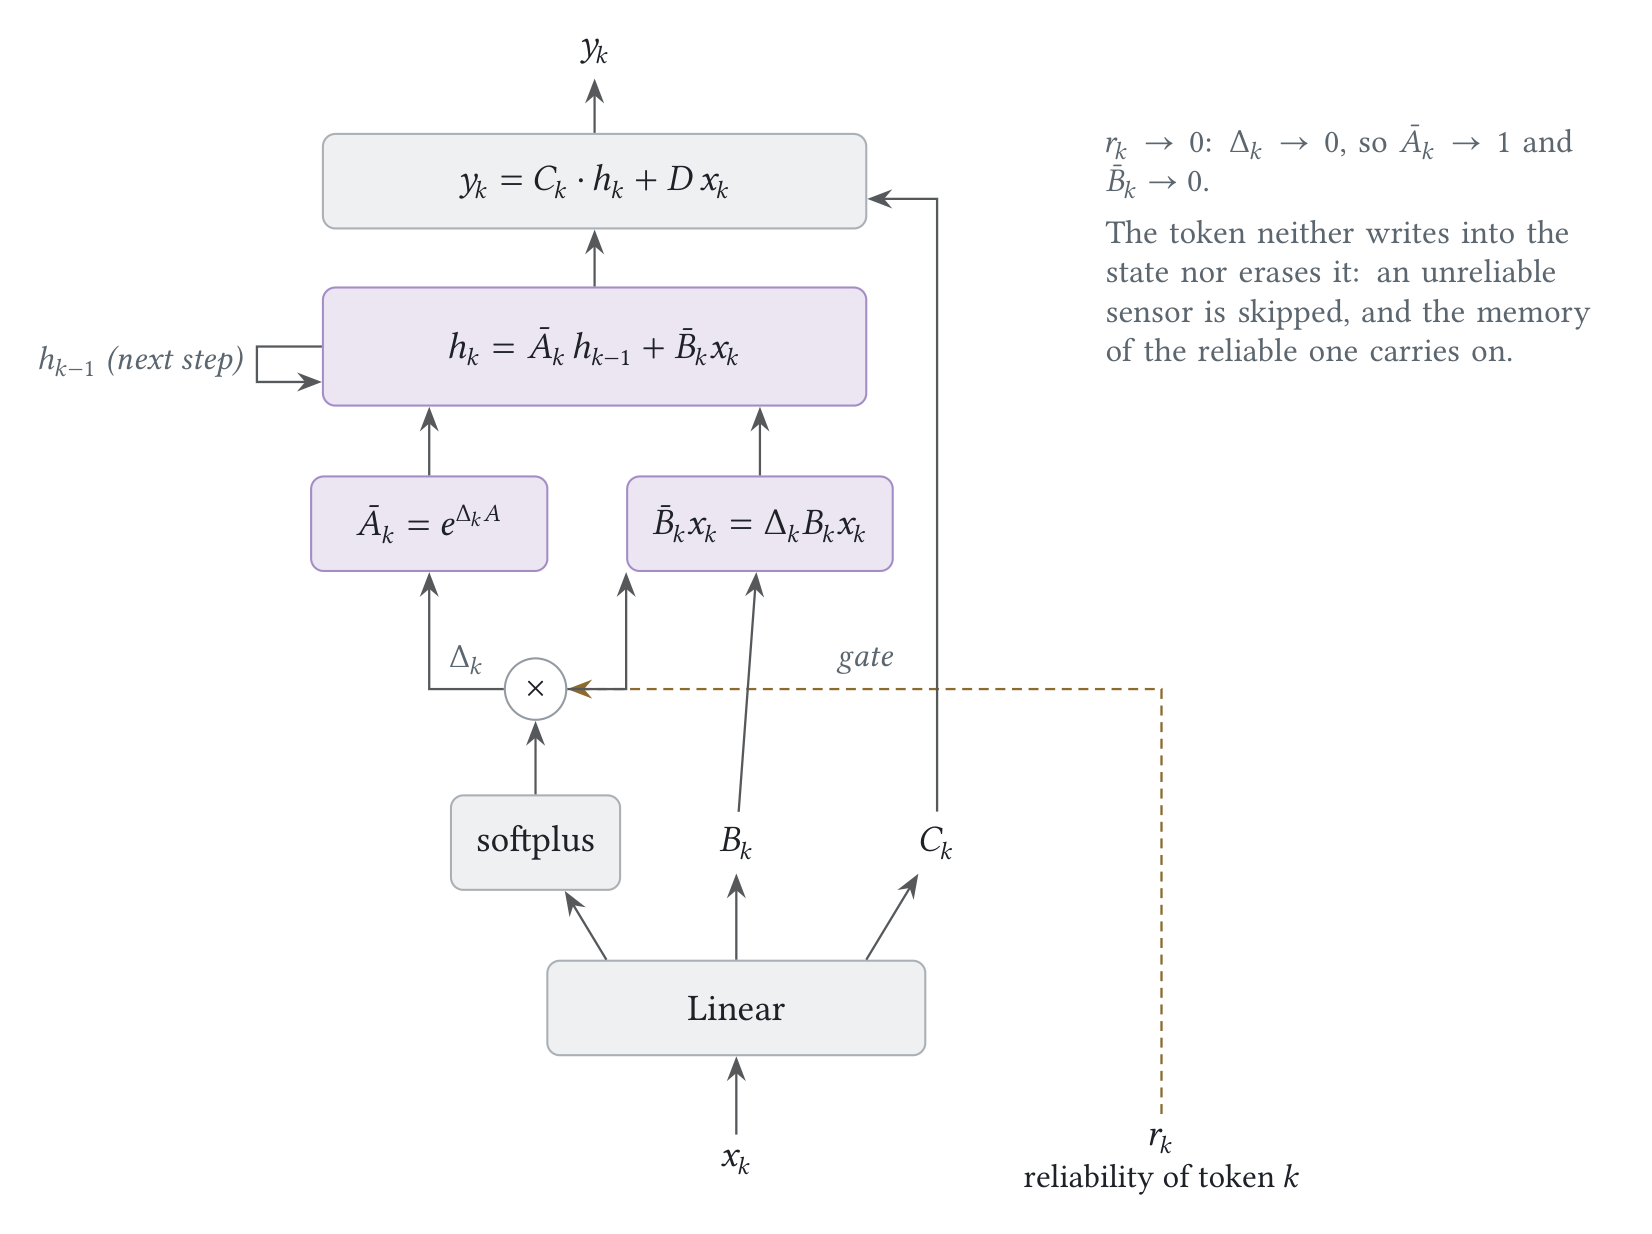

In [4]:
from IPython.display import Image, display
for name in ('fig_gated_scan',):
    f = env.project / "docs" / "figures" / f"{name}.png"
    if f.exists():
        display(Image(filename=str(f), width=640))
    else:
        print("missing", f)

## 1. Where the parameters go

One CMFM block at the stride-8 level of YOLO26-n (128 channels).

In [5]:
import torch, pandas as pd
from cffm.blocks import CMFM, GatedCrossScan
torch.manual_seed(0)
blk = CMFM(128, impl="torch").eval()
rows = [{"part": n, "params": sum(p.numel() for p in m.parameters())} for n, m in blk.named_children()]
df = pd.DataFrame(rows); df.loc[len(df)] = {"part": "total", "params": df["params"].sum()}; df

,part,params
0,rel,4994
1,align,297474
2,phi_v,9024
3,phi_t,9024
4,mixer,8704
5,norm,256
6,local,1408
7,proj,32896
8,total,363780


## 2. A fresh block is a reliability-weighted average

The output projection starts at zero and both reliabilities at sigmoid(2), so before training CMFM returns exactly (F_v + F_t) / 2.

In [6]:
fv, ft = torch.randn(2, 128, 40, 40), torch.randn(2, 128, 40, 40)
z = blk(fv, ft)
print("max |z - (fv + ft)/2| =", (z - (fv + ft) / 2).abs().max().item())

max |z - (fv + ft)/2| = 1.0013580322265625e-05


## 3. The property everything rests on

With thermal reliability zero, perturbing the thermal features must not move the visible outputs at all; with
reliability one, it must.

In [7]:
scan = GatedCrossScan(16, directions=4, impl="torch").eval()
xv, xt = torch.randn(1, 16, 12, 12), torch.randn(1, 16, 12, 12)
ones, zeros = torch.ones(1, 1, 12, 12), torch.zeros(1, 1, 12, 12)
noise = 5 * torch.randn_like(xt)
d_off = (scan(xv, xt, ones, zeros)[0] - scan(xv, xt + noise, ones, zeros)[0]).abs().max().item()
d_on = (scan(xv, xt, ones, ones)[0] - scan(xv, xt + noise, ones, ones)[0]).abs().max().item()
print(f"r_thermal = 0: visible outputs move by {d_off:.2e}   (should be ~0)")
print(f"r_thermal = 1: visible outputs move by {d_on:.2e}   (should be clearly > 0)")

r_thermal = 0: visible outputs move by 0.00e+00   (should be ~0)
r_thermal = 1: visible outputs move by 2.93e+02   (should be clearly > 0)


## 4. Token order

The first scan direction on a 2 x 3 map as (row, column, modality): visible (v) and thermal (t) alternate at every location.

In [8]:
X = torch.zeros(1, 1, 2, 3, 2)
for r in range(2):
    for c in range(3):
        X[0, 0, r, c, 0], X[0, 0, r, c, 1] = 10 * r + c, 100 + 10 * r + c
seq = GatedCrossScan(1, directions=4)._orders(X)[0, 0, 0].int().tolist()
print(" ".join(f"{'t' if s >= 100 else 'v'}({(s % 100) // 10},{s % 10})" for s in seq))

v(0,0) t(0,0) v(0,1) t(0,1) v(0,2) t(0,2) v(1,0) t(1,0) v(1,1) t(1,1) v(1,2) t(1,2)


## 5. Compute of every model, and the matched control

GFLOPs at 640 x 640 include the scans' element-wise work; the gated-convolution control (C4) should sit within a few percent of CFFM-Net.

In [9]:
from cffm.model import DualStreamDetectionModel
from cffm.train import gflops, scan_gflops
rows = []
for cfg in sorted((env.project / "configs" / "models").glob("*.yaml")):
    m = DualStreamDetectionModel(str(cfg), nc=1, verbose=False)
    rows.append({"model": cfg.stem, "params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 3),
                 "GFLOPs": round(gflops(m, 640), 2), "of which scans": round(scan_gflops(m, 640), 3)})
df = pd.DataFrame(rows).set_index("model"); print(df)
ratio = df.loc["cffm-net-n-gconv", "GFLOPs"] / df.loc["cffm-net-n", "GFLOPs"]
print(f"control / CFFM-Net GFLOPs = {ratio:.3f}"); assert abs(ratio - 1) < 0.05

Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


Overriding model.yaml nc=80 with nc=1


                        params (M)  GFLOPs  of which scans
model                                                     
cffm-net-n-gconv             6.154   18.30           0.000
cffm-net-n-nogate            6.009   18.14           0.396
cffm-net-n-nop2              6.017   16.51           0.396
cffm-net-n-v2                6.017   16.51           0.396
cffm-net-n                   6.031   18.39           0.396
two-stream-concat-n-md       4.067    9.71           0.000
two-stream-concat-n          4.067    9.71           0.000
two-stream-concat-p2-n       4.087   11.87           0.000
control / CFFM-Net GFLOPs = 0.995
